In [ ]:
!pip install -q shap

In [ ]:
import sys, json, shutil, tarfile
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

BASE  = Path('/content/drive/MyDrive/Diplom2')
META  = BASE / 'data' / 'meta'
ARC   = BASE / 'data' / 'archives'

CKPT_SIG = BASE / 'checkpoints' / 'transformer_signals'
CKPT_TAB = BASE / 'checkpoints' / 'transformer'
for d in (ARC, CKPT_SIG, CKPT_TAB):
    d.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(BASE / 'code'))

assert torch.cuda.is_available(), 'GPU runtime required'
print('CUDA device:', torch.cuda.get_device_name(0))


Mounted at /content/drive


In [ ]:
LOCAL_SIG = Path('/content/signals_norm.npy')
if not LOCAL_SIG.exists():
    src = ARC / 'normalized.tar'
    print(f'copying {src}  ({src.stat().st_size/1e9:.2f} GB)…')
    shutil.copy(str(src), '/content/normalized.tar')
    with tarfile.open('/content/normalized.tar', 'r') as t:
        t.extractall('/content')
print('signals at', LOCAL_SIG, '|', LOCAL_SIG.stat().st_size / 1e9, 'GB')


copying /content/drive/MyDrive/Diplom2/data/archives/normalized.tar  (16.36 GB)…


/tmp/ipykernel_25380/2379411620.py:7: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  t.extractall('/content')


signals at /content/signals_norm.npy | 16.364812928 GB


In [ ]:
from train import train_model, model_predict
from models import ECGTransformer
from metrics import compute_metrics, plot_roc, save_metrics

norm_meta    = pd.read_csv(META / 'meta_norm.csv')
feature_cols = pd.read_csv(META / 'feature_cols.csv')['feature'].tolist()

train_df = norm_meta[norm_meta['split'] == 'train'].reset_index(drop=True)
val_df   = norm_meta[norm_meta['split'] == 'val'  ].reset_index(drop=True)
test_df  = norm_meta[norm_meta['split'] == 'test' ].reset_index(drop=True)

print(f'train={len(train_df)}  val={len(val_df)}  test={len(test_df)}')
print(f'n_features={len(feature_cols)}')


/tmp/ipykernel_25380/3129984101.py:5: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  norm_meta    = pd.read_csv(META / 'meta_norm.csv')


train=88939  val=14752  test=18071
n_features=205


In [ ]:
_DUMMY = 'dummy_zero'
for df in (train_df, val_df, test_df):
    df[_DUMMY] = 0.0

feature_cols_sig = [_DUMMY]

result_sig = train_model(
    ECGTransformer, train_df, val_df, feature_cols_sig,
    signals_path=LOCAL_SIG,
    save_dir=CKPT_SIG,
    epochs=60, batch_size=128, lr=1e-4, num_workers=4,
)


epoch 001 | train=0.5482 | val=0.3960 | auc=0.6975 | best=0.6975 | lr=2.00e-05 | skipped=0
epoch 002 | train=0.4400 | val=0.3804 | auc=0.7126 | best=0.7126 | lr=4.00e-05 | skipped=0
epoch 003 | train=0.3885 | val=0.3515 | auc=0.7848 | best=0.7848 | lr=6.00e-05 | skipped=0
epoch 004 | train=0.3646 | val=0.3380 | auc=0.7863 | best=0.7863 | lr=8.00e-05 | skipped=0
epoch 005 | train=0.3512 | val=0.2834 | auc=0.7883 | best=0.7883 | lr=1.00e-04 | skipped=0
epoch 006 | train=0.3378 | val=0.2873 | auc=0.8005 | best=0.8005 | lr=9.99e-05 | skipped=0
epoch 007 | train=0.3277 | val=0.2606 | auc=0.8106 | best=0.8106 | lr=9.97e-05 | skipped=0
epoch 008 | train=0.3260 | val=0.2793 | auc=0.8142 | best=0.8142 | lr=9.93e-05 | skipped=0
epoch 009 | train=0.3158 | val=0.2816 | auc=0.8190 | best=0.8190 | lr=9.87e-05 | skipped=0
epoch 010 | train=0.3111 | val=0.2914 | auc=0.8091 | best=0.8190 | lr=9.80e-05 | skipped=0
epoch 011 | train=0.3071 | val=0.2712 | auc=0.8128 | best=0.8190 | lr=9.71e-05 | skipped=0

=== Transformer signal-only ===
{
  "roc_auc": 0.8125353205464524,
  "auc_pr": 0.2882765231931013,
  "top5_recall": 0.3122398001665279,
  "f1": 0.37261698440207974,
  "precision": 0.3884372177055104,
  "recall": 0.35803497085761865,
  "threshold": 0.44146227836608887,
  "n_pos": 1201,
  "n_neg": 16870
}


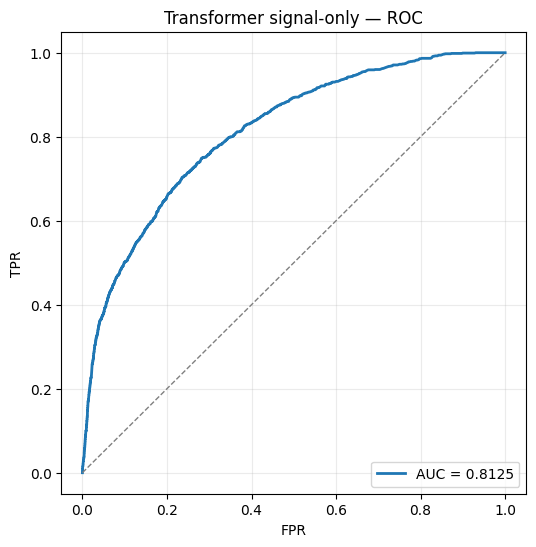

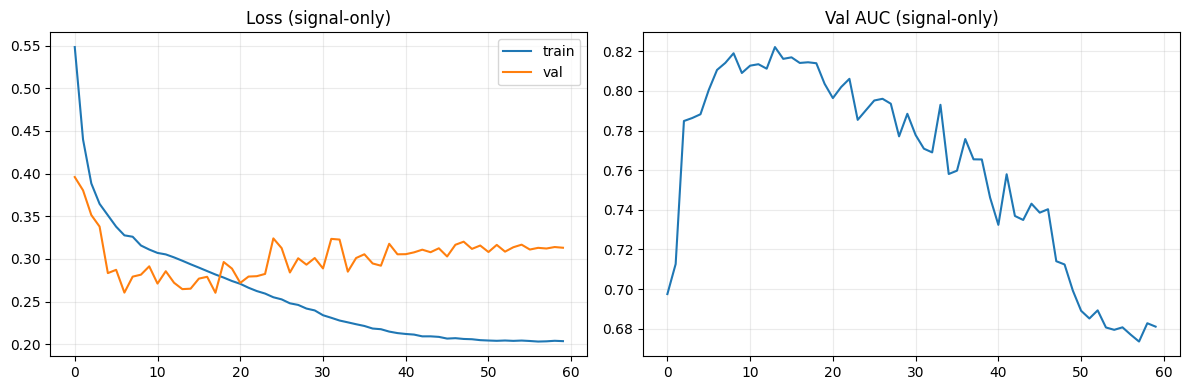

In [ ]:
ckpt_sig  = torch.load(CKPT_SIG / 'best.pt', map_location='cuda')
model_sig = ECGTransformer(n_tab_features=1).cuda()
model_sig.load_state_dict(ckpt_sig['model'])

probs_sig, labels = model_predict(model_sig, test_df, feature_cols_sig, LOCAL_SIG)
metrics_sig = compute_metrics(labels, probs_sig)
print('=== Transformer signal-only ===')
print(json.dumps(metrics_sig, indent=2))
save_metrics(metrics_sig, CKPT_SIG / 'test_metrics.json')
plot_roc(labels, probs_sig, title='Transformer signal-only — ROC',
         savepath=CKPT_SIG / 'roc.png')

pd.DataFrame({
    'record_name':           test_df.get('record_name', pd.RangeIndex(len(test_df))),
    'chagas_label':          labels,
    'transformer_sig_prob':  probs_sig,
}).to_csv(CKPT_SIG / 'test_predictions.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(result_sig['train_losses'], label='train')
axes[0].plot(result_sig['val_losses'],   label='val')
axes[0].set_title('Loss (signal-only)'); axes[0].legend(); axes[0].grid(alpha=.25)
axes[1].plot(result_sig['val_aucs'])
axes[1].set_title('Val AUC (signal-only)'); axes[1].grid(alpha=.25)
plt.tight_layout()
plt.savefig(CKPT_SIG / 'learning_curves.png', dpi=150); plt.show()


In [ ]:
result_tab = train_model(
    ECGTransformer, train_df, val_df, feature_cols,
    signals_path=LOCAL_SIG,
    save_dir=CKPT_TAB,
    epochs=40, batch_size=64, lr=1e-4, num_workers=4,
)


epoch 001 | train=0.5388 | val=0.3688 | auc=0.6805 | best=0.6805 | lr=1.99e-05 | skipped=5
epoch 002 | train=0.4240 | val=0.3147 | auc=0.7705 | best=0.7705 | lr=3.98e-05 | skipped=8
epoch 003 | train=0.3852 | val=0.3045 | auc=0.7648 | best=0.7705 | lr=5.98e-05 | skipped=4
epoch 004 | train=0.3653 | val=0.3155 | auc=0.7864 | best=0.7864 | lr=7.96e-05 | skipped=8
epoch 005 | train=0.3488 | val=0.3384 | auc=0.7916 | best=0.7916 | lr=9.95e-05 | skipped=12
epoch 006 | train=0.3397 | val=0.2962 | auc=0.8111 | best=0.8111 | lr=9.99e-05 | skipped=9
epoch 007 | train=0.3268 | val=0.2742 | auc=0.8217 | best=0.8217 | lr=9.97e-05 | skipped=6
epoch 008 | train=0.3198 | val=0.2552 | auc=0.8233 | best=0.8233 | lr=9.93e-05 | skipped=7
epoch 009 | train=0.3173 | val=0.2800 | auc=0.8319 | best=0.8319 | lr=9.87e-05 | skipped=10
epoch 010 | train=0.3100 | val=0.2584 | auc=0.8340 | best=0.8340 | lr=9.80e-05 | skipped=8
epoch 011 | train=0.3055 | val=0.2474 | auc=0.8351 | best=0.8351 | lr=9.71e-05 | skipped

features: shape=(18071, 205), finite=True, min=-1.85e+04, max=9.15e+04
probs_tab: shape=(18071,), NaN/Inf count=1 / 18071
{
  "roc_auc": 0.835511974559829,
  "auc_pr": 0.32793256293689066,
  "top5_recall": 0.3263946711074105,
  "f1": 0.38327243199350386,
  "precision": 0.37400950871632327,
  "recall": 0.3930058284762698,
  "threshold": 0.43785351514816284,
  "n_pos": 1201,
  "n_neg": 16870
}


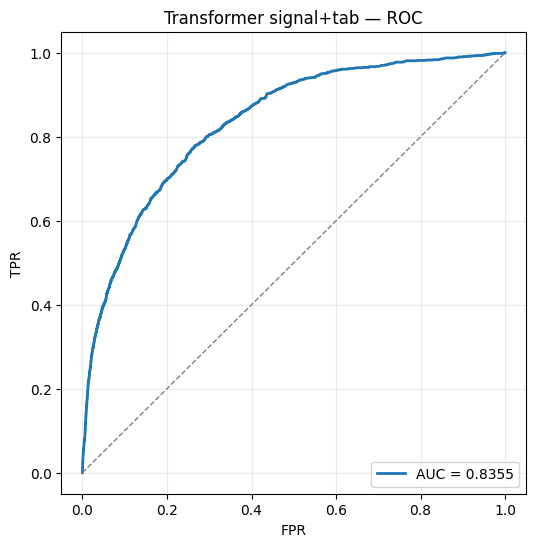

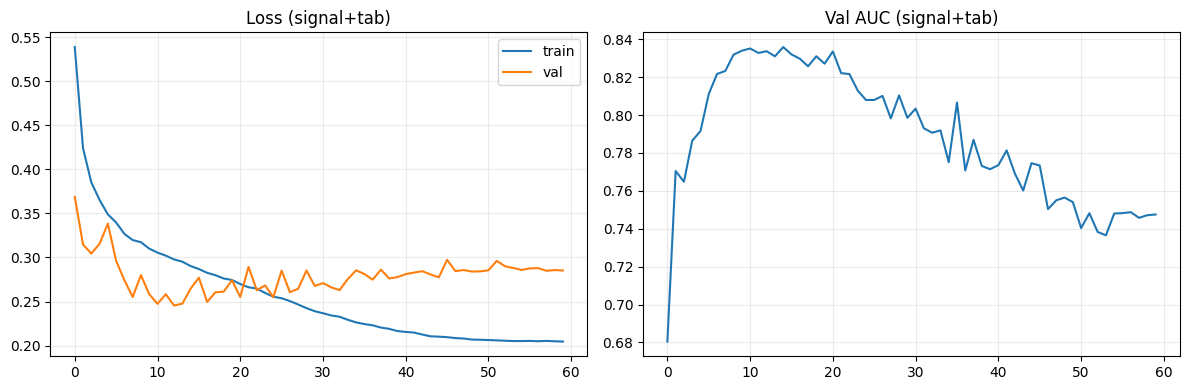

In [ ]:
ckpt_tab  = torch.load(CKPT_TAB / 'best.pt', map_location='cuda')
model_tab = ECGTransformer(n_tab_features=len(feature_cols)).cuda()
model_tab.load_state_dict(ckpt_tab['model'])

for col in feature_cols:
    test_df[col] = pd.to_numeric(test_df[col], errors='coerce')
test_df[feature_cols] = (
    test_df[feature_cols]
    .astype(np.float32)
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0.0)
)

arr = test_df[feature_cols].to_numpy(dtype=np.float32)
print(f'features: shape={arr.shape}, finite={np.isfinite(arr).all()}, '
      f'min={arr.min():.3g}, max={arr.max():.3g}')

probs_tab, _ = model_predict(model_tab, test_df, feature_cols, LOCAL_SIG)

nan_mask = ~np.isfinite(probs_tab)
print(f'probs_tab: shape={probs_tab.shape}, NaN/Inf count={nan_mask.sum()} / {len(probs_tab)}')
if nan_mask.any():
    bad_idx = np.where(nan_mask)[0][:5]
    probs_tab = np.nan_to_num(probs_tab, nan=0.5, posinf=1.0, neginf=0.0)


metrics_tab  = compute_metrics(labels, probs_tab)
print(json.dumps(metrics_tab, indent=2))
save_metrics(metrics_tab, CKPT_TAB / 'test_metrics.json')
plot_roc(labels, probs_tab, title='Transformer signal+tab — ROC',
         savepath=CKPT_TAB / 'roc.png')


pd.DataFrame({
    'record_name':           test_df.get('record_name', pd.RangeIndex(len(test_df))),
    'chagas_label':          labels,
    'transformer_tab_prob':  probs_tab,
}).to_csv(CKPT_TAB / 'test_predictions.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(result_tab['train_losses'], label='train')
axes[0].plot(result_tab['val_losses'],   label='val')
axes[0].set_title('Loss (signal+tab)'); axes[0].legend(); axes[0].grid(alpha=.25)
axes[1].plot(result_tab['val_aucs'])
axes[1].set_title('Val AUC (signal+tab)'); axes[1].grid(alpha=.25)
plt.tight_layout()
plt.savefig(CKPT_TAB / 'learning_curves.png', dpi=150); plt.show()


In [ ]:
compare = pd.DataFrame({
    'model':       ['Transformer signal-only', 'Transformer signal+tab'],
    'ROC-AUC':     [metrics_sig['roc_auc'],    metrics_tab['roc_auc']],
    'AUC-PR':      [metrics_sig['auc_pr'],      metrics_tab['auc_pr']],
    'top5_recall': [metrics_sig['top5_recall'], metrics_tab['top5_recall']],
    'F1':          [metrics_sig['f1'],          metrics_tab['f1']],
}).set_index('model')
print(compare.to_string())
compare.to_csv(BASE / 'checkpoints' / 'transformer_comparison.csv')


                          ROC-AUC    AUC-PR  top5_recall        F1
model                                                             
Transformer signal-only  0.812535  0.288277     0.312240  0.372617
Transformer signal+tab   0.835512  0.327933     0.326395  0.383272



Transformer signal-only — lead importance:
lead  mean_abs_shap
  V6       0.006501
   I       0.006308
  V3       0.005027
 aVL       0.004254
  V4       0.004099
 aVR       0.004022
  V5       0.003941
 III       0.003392
  V1       0.003350
  V2       0.003066
  II       0.002988
 aVF       0.001891


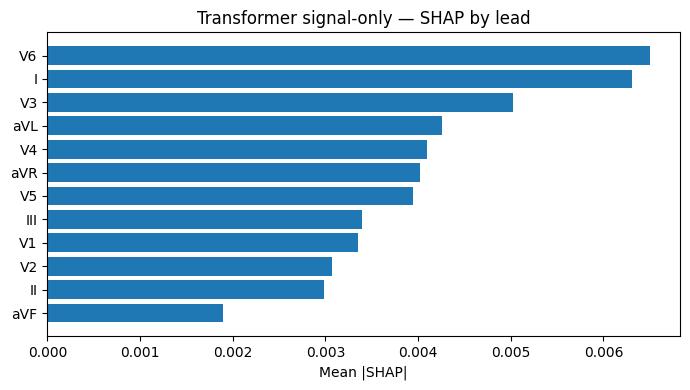


Transformer signal+tab — lead importance:
lead  mean_abs_shap
   I       0.005043
 aVR       0.004773
  V4       0.003762
  V6       0.003595
  V5       0.003463
  V3       0.002965
 aVL       0.002286
  V1       0.002126
  V2       0.002045
  II       0.001916
 aVF       0.001685
 III       0.001453


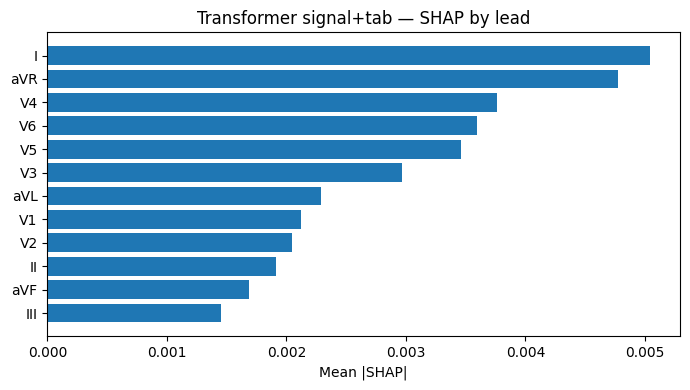

/tmp/ipykernel_25380/4159932696.py:56: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_tab_st, ex_tab_vals, feature_names=feature_cols,


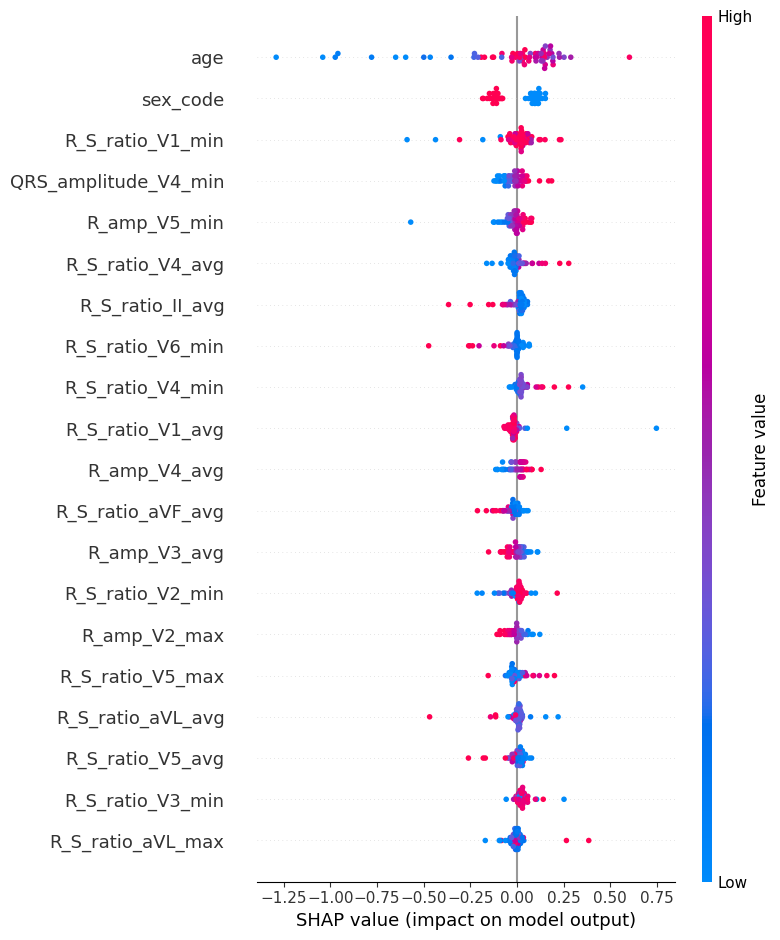

In [ ]:
import shap

LEAD_NAMES = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']
signals    = np.load(str(LOCAL_SIG), mmap_mode='r')
N_BG, N_EXPLAIN = 32, 64


def _load_batch(df, feat_cols, idx_col='norm_idx', device='cuda'):
    idxs = df[idx_col].astype(int).to_numpy()
    sigs = np.stack([np.asarray(signals[i]).T for i in idxs]).astype(np.float32)
    tabs = df[feat_cols].to_numpy(dtype=np.float32)
    tabs = np.nan_to_num(tabs, nan=0.0)
    return (torch.from_numpy(sigs).to(device),
            torch.from_numpy(tabs).to(device))


def shap_per_lead(model, feat_cols, ckpt_dir, model_name, device='cuda'):
    model.eval()
    bg_sig,  bg_tab  = _load_batch(train_df.sample(N_BG,      random_state=42).reset_index(drop=True),
                                    feat_cols, device=device)
    ex_sig,  ex_tab  = _load_batch(test_df .sample(N_EXPLAIN,  random_state=42).reset_index(drop=True),
                                    feat_cols, device=device)

    explainer   = shap.GradientExplainer(model, [bg_sig, bg_tab])
    shap_values = explainer.shap_values([ex_sig, ex_tab])

    shap_sig = np.asarray(shap_values[0])
    shap_tab = np.asarray(shap_values[1])
    if shap_sig.ndim == 4 and shap_sig.shape[-1] == 1:
        shap_sig = shap_sig[..., 0]
    if shap_tab.ndim == 3 and shap_tab.shape[-1] == 1:
        shap_tab = shap_tab[..., 0]

    lead_imp = np.mean(np.abs(shap_sig), axis=(0, 2))
    lead_fi  = pd.DataFrame({'lead': LEAD_NAMES, 'mean_abs_shap': lead_imp})
    lead_fi  = lead_fi.sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
    print(f'\n{model_name} — lead importance:')
    print(lead_fi.to_string(index=False))
    lead_fi.to_csv(ckpt_dir / 'shap_lead_importance.csv', index=False)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.barh(lead_fi['lead'].iloc[::-1], lead_fi['mean_abs_shap'].iloc[::-1])
    ax.set_xlabel('Mean |SHAP|'); ax.set_title(f'{model_name} — SHAP by lead')
    plt.tight_layout()
    plt.savefig(ckpt_dir / 'shap_lead_importance.png', dpi=150); plt.show()

    return shap_sig, shap_tab, ex_tab.cpu().numpy()


shap_sig_so, _, _ = shap_per_lead(model_sig, feature_cols_sig, CKPT_SIG,
                                   'Transformer signal-only')

shap_sig_st, shap_tab_st, ex_tab_vals = shap_per_lead(model_tab, feature_cols,
                                                        CKPT_TAB, 'Transformer signal+tab')

shap.summary_plot(shap_tab_st, ex_tab_vals, feature_names=feature_cols,
                  max_display=20, show=False)
plt.tight_layout()
plt.savefig(CKPT_TAB / 'shap_tabular_summary.png', dpi=150, bbox_inches='tight')
plt.show()
